In [1]:
import pandas as pd

# Option 1: If you already have a CSV file
# df = pd.read_csv("your_file.csv")

# Option 2: If you want to test with sample data (recommended first run)
data = {
    "IP": [
        "222.166.160.184",
        "63.13.186.196",
        "147.31.138.75",
        "207.203.80.15",
        "218.76.139.20",
        "24.147.151.74",
        "211.141.93.88",
        "216.127.124.16",
        "208.51.151.210",
        "65.68.235.27"
    ],
    "Threat_Score": [5, 15, 45, 75, 90, 30, 60, 10, 50, 85]
}

df = pd.DataFrame(data)
df.head()

,IP,Threat_Score
0,222.166.160.184,5
1,63.13.186.196,15
2,147.31.138.75,45
3,207.203.80.15,75
4,218.76.139.20,90


=== KPI SUMMARY ===
Total IPs: 10
Unique IPs: 10
Critical IPs: 2
High IPs: 1
Average Score: 46.5
Max Score: 90


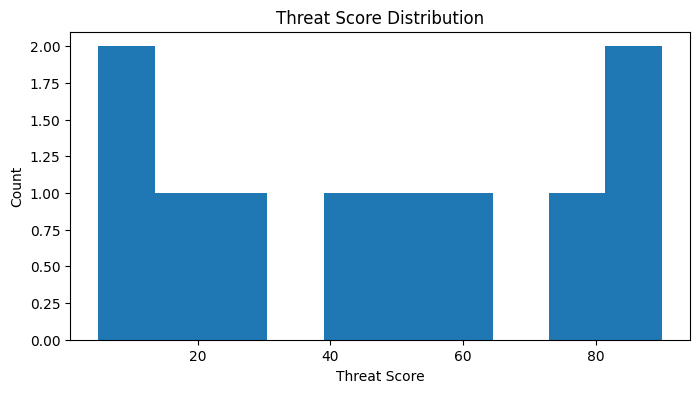

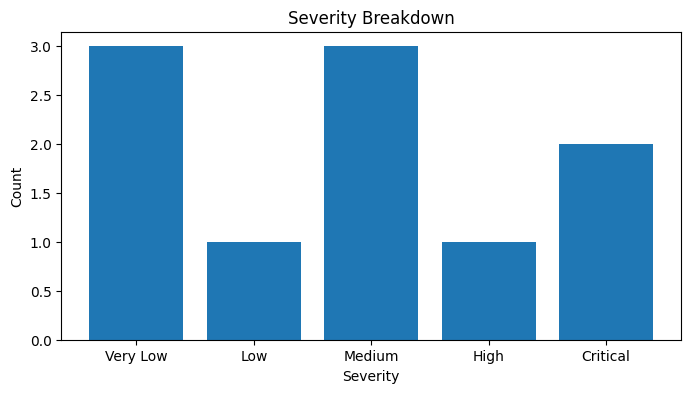


=== TOP RISKY IPS ===


,ip,threat_score,severity,reason
4,218.76.139.20,90,Critical,High-risk IP (multiple malicious indicators)
9,65.68.235.27,85,Critical,High-risk IP (multiple malicious indicators)
3,207.203.80.15,75,High,Suspicious behavior detected
6,211.141.93.88,60,Medium,Suspicious behavior detected
8,208.51.151.210,50,Medium,Moderate anomaly score
2,147.31.138.75,45,Medium,Moderate anomaly score
5,24.147.151.74,30,Low,Low confidence / background noise
1,63.13.186.196,15,Very Low,Low confidence / background noise
7,216.127.124.16,10,Very Low,Low confidence / background noise
0,222.166.160.184,5,Very Low,Low confidence / background noise



Files exported:
- soc_alerts_top20.csv
- soc_ip_risk_feed.json


In [2]:
import numpy as np
import ipaddress
import matplotlib.pyplot as plt

# ----------------------------
# 1. Standardize column names
# ----------------------------
df = df.copy()
df.rename(columns={"IP": "ip", "Threat_Score": "threat_score"}, inplace=True)

# ----------------------------
# 2. Validate IPs
# ----------------------------
def valid_ip(x):
    try:
        ipaddress.ip_address(str(x))
        return True
    except:
        return False

df["valid_ip"] = df["ip"].apply(valid_ip)
df = df[df["valid_ip"]].drop(columns=["valid_ip"])

# ----------------------------
# 3. Severity Classification
# ----------------------------
df["severity"] = pd.cut(
    df["threat_score"],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=["Very Low", "Low", "Medium", "High", "Critical"]
)

# ----------------------------
# 4. Explainability (Reason)
# ----------------------------
def reason(score):
    if score >= 80:
        return "High-risk IP (multiple malicious indicators)"
    elif score >= 60:
        return "Suspicious behavior detected"
    elif score >= 40:
        return "Moderate anomaly score"
    else:
        return "Low confidence / background noise"

df["reason"] = df["threat_score"].apply(reason)

# ----------------------------
# 5. KPI Summary
# ----------------------------
kpis = {
    "Total IPs": len(df),
    "Unique IPs": df["ip"].nunique(),
    "Critical IPs": (df["severity"] == "Critical").sum(),
    "High IPs": (df["severity"] == "High").sum(),
    "Average Score": round(df["threat_score"].mean(), 2),
    "Max Score": df["threat_score"].max()
}

print("=== KPI SUMMARY ===")
for k, v in kpis.items():
    print(f"{k}: {v}")

# ----------------------------
# 6. Threat Score Distribution
# ----------------------------
plt.figure(figsize=(8,4))
plt.hist(df["threat_score"], bins=10)
plt.title("Threat Score Distribution")
plt.xlabel("Threat Score")
plt.ylabel("Count")
plt.show()

# ----------------------------
# 7. Severity Breakdown
# ----------------------------
sev_counts = df["severity"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(sev_counts.index.astype(str), sev_counts.values)
plt.title("Severity Breakdown")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

# ----------------------------
# 8. Top Risky IPs
# ----------------------------
top_alerts = df.sort_values("threat_score", ascending=False)

print("\n=== TOP RISKY IPS ===")
display(top_alerts)

# ----------------------------
# 9. Export Files
# ----------------------------
top_alerts.to_csv("soc_alerts_top20.csv", index=False)
df.to_json("soc_ip_risk_feed.json", orient="records")

print("\nFiles exported:")
print("- soc_alerts_top20.csv")
print("- soc_ip_risk_feed.json")